In [1]:
import pandas as pd
import os
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
import matplotlib.pyplot as plt
import itertools
sns.set_theme(style="darkgrid", font_scale=1.5)

# Show current working directory
# print("Current Working Directory: ", os.getcwd())

# File paths
aws_path = 'C:/Users/simon/OneDrive - University of Copenhagen/Documents/Arbeitsmappe/GEMLST/data4simon/AWS/aws_temperature.csv'

In [2]:
# Load data
aws_data = pd.read_csv(aws_path)
# print(aws_data.columns)

# # List all files in the directory "Data/2022"
# print(os.listdir('./Data/2022'))

### MODIS
# 2003 - orbital drift
# modd_data0 = pd.read_csv('./Data/2003/GEM_2003_AWS_MOD_DAY_LST_bit6lte0.csv') # The coeffeicients for 0 and 1 were significantly different. Go with 1 (Error <= 2K)
# mydd_data0 = pd.read_csv('./Data/2003/GEM_2003_AWS_MYD_DAY_LST_bit6lte0.csv')
modd_data1 = pd.read_csv('./Data/2003/GEM_2003_AWS_MOD_DAY_LST_bit6lte1.csv')
modn_data1 = pd.read_csv('./Data/2003/GEM_2003_AWS_MOD_NIGHT_LST_bit6lte1.csv')
mydd_data1 = pd.read_csv('./Data/2003/GEM_2003_AWS_MYD_DAY_LST_bit6lte1.csv')
mydn_data1 = pd.read_csv('./Data/2003/GEM_2003_AWS_MYD_NIGHT_LST_bit6lte1.csv')

# # 2022
# modd_data0 = pd.read_csv('./Data/2022/GEM_2022_AWS_MOD_DAY_LST_bit6lte0.csv')
# mydd_data0 = pd.read_csv('./Data/2022/GEM_2022_AWS_MYD_DAY_LST_bit6lte0.csv')
# modd_data1 = pd.read_csv('./Data/2022/GEM_2022_AWS_MOD_DAY_LST_bit6lte1.csv')
# modn_data1 = pd.read_csv('./Data/2022/GEM_2022_AWS_MOD_NIGHT_LST_bit6lte1.csv')
# mydd_data1 = pd.read_csv('./Data/2022/GEM_2022_AWS_MYD_DAY_LST_bit6lte1.csv')
# mydn_data1 = pd.read_csv('./Data/2022/GEM_2022_AWS_MYD_NIGHT_LST_bit6lte1.csv')

## 2024
## Read .xlsx files from the folder "Data" in the working directory
# modd_data0 = pd.read_excel('./Data/2024/GEM_AWS_MOD_DAY_LST_bit6lte0.xlsx')
# modd_data1 = pd.read_excel('./Data/2024/GEM_AWS_MOD_DAY_LST_bit6lte1.xlsx')
# modn_data1 = pd.read_excel('./Data/2024/GEM_AWS_MOD_NIGHT_LST_bit6lte1.xlsx')
# mydd_data0 = pd.read_excel('./Data/2024/GEM_AWS_MYD_DAY_LST_bit6lte0.xlsx')
# mydd_data1 = pd.read_excel('./Data/2024/GEM_AWS_MYD_DAY_LST_bit6lte1.xlsx')
# mydn_data1 = pd.read_excel('./Data/2024/GEM_AWS_MYD_NIGHT_LST_bit6lte1.xlsx')

### JAXA GCOM 
# jaxa_a_data = pd.read_csv('./Data/JAXA_V3/GEM_2024_AWS_JAXA_A_LST.csv')
# jaxa_d_data = pd.read_csv('./Data/JAXA_V3/GEM_2024_AWS_JAXA_D_LST.csv')

### VIIRS
viirs_day_data = pd.read_csv('./Data/VIIRS/GEM_AWS_VIIRS_DAY_LST.csv')
viirs_night_data = pd.read_csv('./Data/VIIRS/GEM_AWS_VIIRS_NIGHT_LST.csv')

### ERA5 data

# era5_data = pd.read_csv('./Data/ERA5/GEM_AWS_ERA5_LST.csv')


In [3]:
## Process AWS data (group by Date and station), if necessary 
aws_data['Date'] = pd.to_datetime(aws_data['Date']).dt.date
# aws_data['day'] = aws_data['Date']
# aws_data_mean = (
#     aws_data.groupby(['aws', 'day'], as_index=False)['temperature']
#             .mean()
#             .rename(columns={'temperature': 'mean_temperature', 'day': 'Date'})
# )


# Process modis data
# modd_data0['Date'] = pd.to_datetime(modd_data0['system:time_start'], unit='ms').dt.date
# modd_data0 = modd_data0.rename(columns={'id': 'aws', 'MOD_LST_Day':'est_temp'})
# modd_data0['aws'] = modd_data0['aws'].replace('Zackenberg_M4_30min', 'Zackenberg_M4')

modd_data1['Date'] = pd.to_datetime(modd_data1['system:time_start'], unit='ms').dt.date
modd_data1 = modd_data1.rename(columns={'id': 'aws', 'MOD_LST_Day':'est_temp'})
modd_data1['aws'] = modd_data1['aws'].replace('Zackenberg_M4_30min', 'Zackenberg_M4')

modn_data1['Date'] = pd.to_datetime(modn_data1['system:time_start'], unit='ms').dt.date
modn_data1 = modn_data1.rename(columns={'id': 'aws', 'MOD_LST_Night':'est_temp'})
modn_data1['aws'] = modn_data1['aws'].replace('Zackenberg_M4_30min', 'Zackenberg_M4')

# mydd_data0['Date'] = pd.to_datetime(mydd_data0['system:time_start'], unit='ms').dt.date
# mydd_data0 = mydd_data0.rename(columns={'id': 'aws', 'MYD_LST_Day':'est_temp'})
# mydd_data0['aws'] = mydd_data0['aws'].replace('Zackenberg_M4_30min', 'Zackenberg_M4')

mydd_data1['Date'] = pd.to_datetime(mydd_data1['system:time_start'], unit='ms').dt.date
mydd_data1 = mydd_data1.rename(columns={'id': 'aws', 'MYD_LST_Day':'est_temp'})
mydd_data1['aws'] = mydd_data1['aws'].replace('Zackenberg_M4_30min', 'Zackenberg_M4')

mydn_data1['Date'] = pd.to_datetime(mydn_data1['system:time_start'], unit='ms').dt.date
mydn_data1 = mydn_data1.rename(columns={'id': 'aws', 'MYD_LST_Night':'est_temp'})
mydn_data1['aws'] = mydn_data1['aws'].replace('Zackenberg_M4_30min', 'Zackenberg_M4')

# Process Jaxa data
# jaxa_a_data['Date'] = pd.to_datetime(jaxa_a_data['system:time_start'], unit='ms').dt.date
# jaxa_a_data = jaxa_a_data.rename(columns={'id': 'aws', 'JAXA_LST_AVE':'est_temp'})
# jaxa_a_data['aws'] = jaxa_a_data['aws'].replace('Zackenberg_M4_30min', 'Zackenberg_M4')

# jaxa_d_data['Date'] = pd.to_datetime(jaxa_a_data['system:time_start'], unit='ms').dt.date
# jaxa_d_data = jaxa_d_data.rename(columns={'id': 'aws', 'JAXA_LST_AVE':'est_temp'})
# jaxa_d_data['aws'] = jaxa_d_data['aws'].replace('Zackenberg_M4_30min', 'Zackenberg_M4')


# Process VIIRS data
viirs_day_data['Date'] = pd.to_datetime(viirs_day_data['date']).dt.date
viirs_day_data = viirs_day_data.rename(columns={'id': 'aws', 'VIIRS_LST_1KM_C':'est_temp'})
viirs_day_data['aws'] = viirs_day_data['aws'].replace('Zackenberg_M4_30min', 'Zackenberg_M4')

viirs_night_data['Date'] = pd.to_datetime(viirs_night_data['date']).dt.date
viirs_night_data = viirs_night_data.rename(columns={'id': 'aws', 'VIIRS_LST_1KM_C':'est_temp'})
viirs_night_data['aws'] = viirs_night_data['aws'].replace('Zackenberg_M4_30min', 'Zackenberg_M4')


In [4]:
# # print(modd_data0.dtypes, '\n')
# # print(aws_data_mean.dtypes)
# # print(type(aws_data['Date']))
# # print(type(modd_data0['Date']))

# # print(aws_data['aws'].unique())
# # print(modd_data0['aws'].unique())


# # Merge each of the datasets with AWS data using nearest time within 1 hour tolerance
# df_modd0 = pd.merge(
#     aws_data,
#     modd_data0,
#     on=['aws', 'Date'],
#     how='inner'
# )
# df_modd0 = df_modd0.dropna()

df_modd1 = pd.merge(
    aws_data,
    modd_data1,
    on=['aws', 'Date'],
    how='inner'
)
df_modd1 = df_modd1.dropna()

df_modn1 = pd.merge(
    aws_data,
    modn_data1,
    on=['aws', 'Date'],
    how='inner'
)
df_modn1 = df_modn1.dropna()

# df_mydd0 = pd.merge(
#     aws_data,
#     mydd_data0,
#     on=['aws', 'Date'],
#     how='inner'
# )
# df_mydd0 = df_mydd0.dropna()

df_mydd1 = pd.merge(
    aws_data,
    mydd_data1,
    on=['aws', 'Date'],
    how='inner'
)
df_mydd1 = df_mydd1.dropna()

df_mydn1 = pd.merge(
    aws_data,
    mydn_data1,
    on=['aws', 'Date'],
    how='inner'
)
df_mydn1 = df_mydn1.dropna()

# df_jaxa_a = pd.merge(
#     aws_data,
#     jaxa_a_data,
#     on=['aws', 'Date'],
#     how='inner'
# )
# df_jaxa_a = df_jaxa_a.dropna()

# df_jaxa_d = pd.merge(
#     aws_data,
#     jaxa_d_data,
#     on=['aws', 'Date'],
#     how='inner'
# )
# df_jaxa_d = df_jaxa_d.dropna()

df_viirs_day = pd.merge(
    aws_data, 
    viirs_day_data,
    on=['aws', 'Date'],
    how='inner'
)
df_viirs_day = df_viirs_day.dropna()

df_viirs_night = pd.merge(
    aws_data,
    viirs_night_data,
    on=['aws', 'Date'],
    how='inner'
)
df_viirs_night = df_viirs_night.dropna()


In [5]:
# print(len(df_modd1))
# print(len(df_modn1))
# print(len(df_mydd1))
# print(len(df_mydn1))

# print('\nJAXA A: ', len(df_jaxa_a))
# print('JAXA D: ', len(df_jaxa_d))

print('\nVIIRS Day: ', len(df_viirs_day))
print('VIIRS Night: ', len(df_viirs_night))


VIIRS Day:  9689
VIIRS Night:  7705


In [ ]:
dfs = [df_modd1, df_modn1, df_mydd1, df_mydn1, df_viirs_day, df_viirs_night]
labels = ["MOD_Terra_DAY", "MOD_Terra_NIGHT", "MYD_Aqua_DAY", "MYD_Aqua_NIGHT", "VIIRS_DAY", "VIIRS_NIGHT"]

def split_mod_viz(df):
    # Split data into training and testing sets (2/3 training, 1/3 testing)
    train_df, test_df = train_test_split(df, test_size=0.33, random_state=42)

    # Regression model fit and prediction
    model = LinearRegression()
    model.fit(train_df[['est_temp']], train_df['temperature'])
    model.predict(test_df[['est_temp']])
    r2_train = round(model.score(train_df[['est_temp']], train_df['temperature']), 2)

    # Apply calibration to test dataset
    test_df['lst_calibrated'] = test_df['est_temp'] * model.coef_[0] + model.intercept_
    test_df = test_df[test_df['lst_calibrated'] <= 0]

    # Reveal coefficients of the calibrated model
    model2 = LinearRegression()
    model2.fit(test_df[['lst_calibrated']], test_df['temperature'])
    r2_test = round(model2.score(test_df[['lst_calibrated']], test_df['temperature']), 2)

    return {
        "n_obs": len(df),
        "coef_before": model.coef_[0],
        "intercept_before": model.intercept_,
        "R-squared_before": r2_train,
        "rmse_before": ((test_df['est_temp'] - test_df['temperature']) ** 2).mean() ** 0.5,
        "coef_calibrated": model2.coef_[0],
        "intercept_corrected": model2.intercept_,
        "R-squared_after": r2_test,
        "rmse_after": ((test_df['est_temp'] * model.coef_[0] + model.intercept_ - test_df['temperature']) ** 2).mean() ** 0.5
        }

    # # The coefficients
    # print('No. of observations (total df): ', len(df))
    # print('Coefficients: ', model.coef_)
    # print('Intercept: ', model.intercept_)
    # print('R-squared: ', model.score(test_df[['est_temp']], test_df['temperature']))

    # # Apply calibration to test dataset
    # test_df['lst_calibrated'] = test_df['est_temp'] * model.coef_[0] + model.intercept_

    # # Calculate RMSE of the calibration results
    # rmse_before = ((test_df['est_temp'] - test_df['temperature']) ** 2).mean() ** 0.5
    # rmse_after = ((test_df['lst_calibrated'] - test_df['temperature']) ** 2).mean() ** 0.5
    # print(f"RMSE before calibration: {rmse_before:.2f} °C")
    # print(f"RMSE after calibration: {rmse_after:.2f} °C\n")

    # # Create comparison plot of original vs calibrated values
    # fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 10))

    # # Add 1:1 reference line 
    # min_val = min(test_df['est_temp'].min(), test_df['temperature'].min())
    # max_val = max(test_df['est_temp'].max(), test_df['temperature'].max())

    # # 2d HISTOGRAM PLOTS
    # # Original est_temp plot
    # sns.histplot(ax=ax1, data=train_df, x='est_temp', y='temperature', bins=60, discrete=True)
    # sns.regplot(ax=ax1, data=test_df, x='est_temp', y='temperature', scatter=False, color='red')
    # ax1.plot([min_val, max_val], [min_val, max_val], '--', color='gray', alpha=0.8)
    # ax1.set_xlabel('Original LST (°C)')
    # ax1.set_ylabel('AWS Temperature (°C)')
    # ax1.set_title('Before Calibration (Training Data)')
    # ax1.set_aspect('equal')

    # # Calibrated est_temp plot
    # sns.histplot(ax=ax2, data=test_df, x='lst_calibrated', y='temperature', bins=60, discrete=True)
    # sns.regplot(ax=ax2, data=test_df, x='lst_calibrated', y='temperature', scatter=False, color='red')
    # ax2.plot([min_val, max_val], [min_val, max_val], '--', color='gray', alpha=0.8)
    # ax2.set_xlabel('Calibrated LST (°C)')
    # ax2.set_ylabel('AWS Temperature (°C)')
    # ax2.set_title('After Calibration (Test Data)')
    # ax2.set_aspect('equal')

    # plt.tight_layout()
    # plt.show()

results = [] 

for r in range(1, len(dfs) + 1):
    for idxs in itertools.combinations(range(len(dfs)), r):
        combo_labels = [labels[i] for i in idxs]
        combo_dfs = [dfs[i] for i in idxs]

        # Merge all selected datasets
        # Assuming they can be merged on a common key (e.g. "pixel_id" or time)
        df_merged = pd.concat(combo_dfs)

        # Run regression
        result = split_mod_viz(df_merged)
        result["Combination"] = " + ".join(combo_labels)
        results.append(result)

# --- Create a summary table ---
df_results = pd.DataFrame(results)
print(df_results.head())

df_results.to_csv('./Data/SKL_Coefficients_Land_comb.csv', index=False)



# For large amounts of data, consider a 2d hist, kernel density or vaex plot
# https://seaborn.pydata.org/generated/seaborn.kdeplot.html
# https://seaborn.pydata.org/generated/seaborn.histplot.html
# https://vaex.io/docs/index.html


   n_obs  coef_before  intercept_before  R-squared_before  rmse_before  \
0  14073     0.757255         -1.437257              0.88     5.900830   
1  13275     0.931188          4.503018              0.86     7.450110   
2  14510     0.776829         -1.503167              0.91     5.088809   
3  13237     0.998089          6.139989              0.84     8.336684   
4   9689     0.763744         -1.803153              0.93     4.178201   

   coef_calibrated  intercept_corrected  R-squared_after  rmse_after  \
0         1.000277            -0.190286             0.70    4.872415   
1         1.000367            -0.269691             0.70    5.003702   
2         1.045093             0.531486             0.77    4.321331   
3         0.894866            -1.502565             0.62    5.751793   
4         1.098116             1.383973             0.85    3.422638   

       Combination  
0    MOD_Terra_DAY  
1  MOD_Terra_NIGHT  
2     MYD_Aqua_DAY  
3   MYD_Aqua_NIGHT  
4        VIIRS_DA

### Significance test of the coefficients 
Test whether the coefficients of bit6=0 and bit6=1 datasets are significantly different. If they are not significantly different, we might want to run the analysis with the larger dataset (bit6=0). 

In [14]:
import statsmodels.formula.api as smf

df_modd0['group'] = 'MOD_DAY_bit6=0'
df_modd1['group'] = 'MOD_DAY_bit6=1'
df_mydd0['group'] = 'MYD_DAY_bit6=0'
df_mydd1['group'] = 'MYD_DAY_bit6=1'

df_modd1010 = pd.concat([df_modd0, df_modd1])
df_mydd1010 = pd.concat([df_mydd0, df_mydd1])

print(df_modd1010.columns.unique())

sigcoef_mod = smf.ols("temperature ~ est_temp * group", data=df_modd1010).fit()
print(sigcoef_mod.summary())

sigcoef_myd = smf.ols("temperature ~ est_temp * group", data=df_mydd1010).fit()
print(sigcoef_myd.summary())

# The dummy variable "group" has a significant effect on the slope if the p-value of the interaction term (est_temp:group) is less than 0.05.

NameError: name 'df_modd0' is not defined

C:\Users\simon\AppData\Local\Temp\ipykernel_2508\3795880245.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  mod_outlier['date'] = pd.to_datetime(mod_outlier['date'])
C:\Users\simon\AppData\Local\Temp\ipykernel_2508\3795880245.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  mod_outlier['daynight'] = mod_outlier['date'].apply(lambda x: 'day' if 6 <= x.hour < 18 else 'night')
C:\Users\simon\AppData\Local\Temp\ipykernel_2508\3795880245.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy

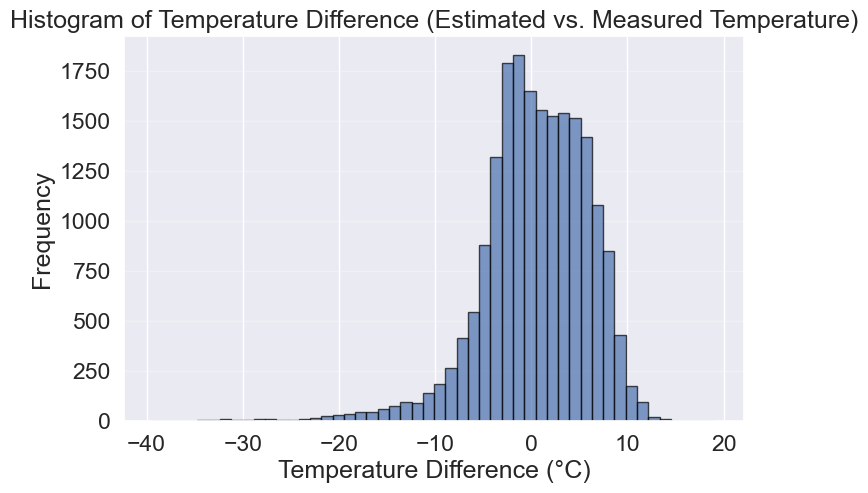

,aws,counts
1,Kobbefjord_M500,297
3,Zackenberg_M3,216
0,Disko_AWS2,196
2,Zackenberg_M2,185
4,Zackenberg_M4,145


In [ ]:
# Take a closer look at the outliers. 

df_modd1010['temp_diff'] = (df_modd1010['est_temp'] - df_modd1010['temperature'])
mod_outlier = df_modd1010[df_modd1010['temp_diff'].abs() > 10]
mod_outlier['date'] = pd.to_datetime(mod_outlier['date'])
mod_outlier['daynight'] = mod_outlier['date'].apply(lambda x: 'day' if 6 <= x.hour < 18 else 'night')
mod_outlier['month'] = mod_outlier['date'].dt.month

plt.figure(figsize=(8,5))
plt.hist(df_modd1010["temp_diff"], bins=50, edgecolor='black', alpha=0.7)
plt.title("Histogram of Temperature Difference (Estimated vs. Measured Temperature)")
plt.xlabel("Temperature Difference (°C)")
plt.ylabel("Frequency")
plt.grid(axis='y', alpha=0.3)
plt.show()

mod_outlier.describe()

# # Create a scatter plot of df_modd1010 with calibrated LST vs temperature and add the points from mod_outlier in red
# fig, ax = plt.subplots()
# min_val = min(df_modd1010['est_temp'].min(), df_modd1010['temperature'].min())
# max_val = max(df_modd1010['est_temp'].max(), df_modd1010['temperature'].max())
# sns.scatterplot(data=df_modd1010, x='est_temp', y='temperature', alpha=0.5, color='black')
# sns.scatterplot(data=mod_outlier, x='est_temp', y='temperature', color='red', label= f'Outliers: {len(mod_outlier)}')
# sns.regplot(data=df_modd1010, x='est_temp', y='temperature', scatter=False, color='red')
# ax.plot([min_val, max_val], [min_val, max_val], '--', color='gray', alpha=0.8)
# ax.set_xlabel('Calibrated LST (°C)')
# ax.set_ylabel('AWS Temperature (°C)')
# plt.tight_layout()
# plt.show()

# mod_outlier.describe(include='all')

mod_outlier.groupby('aws').size().reset_index(name='counts').sort_values(by='counts', ascending=False)